# AAI614: Data Science & its Applications

*Notebook 2.5: Practice with Parquet and File Types*
<a href="https://colab.research.google.com/github/engmahmoudelhassan-cell/AAI614_Elhassan/blob/Week%202/Notebook2.5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For this experiment, i tested three sizes saved three ways each (Parquet, CSV, zipped CSV). Each size is checked on its own below. The three formats for a size are read one file at a time, put in a small table, and drawn as a bar chart so the difference is easy to see.

- **small** = niaaa-report (1,683 rows)
- **medium** = 1,000,000 rows
- **large** = 3,000,000 rows

In [1]:
import pandas as pd
import time
import matplotlib.pyplot as plt

In [2]:
class Timer:
    def __enter__(self):
        self.start = time.perf_counter()
        return self

    def __exit__(self, *args):
        self.end = time.perf_counter()
        self.interval = self.end - self.start

In [3]:
base = 'https://raw.githubusercontent.com/engmahmoudelhassan-cell/AAI614_Elhassan/main/Week%202/data/'

# one dict per file size
small = {}
medium = {}
large = {}

# same colour for a format
colors = {'parquet': '#4C72B0', 'csv': '#DD8452', 'zip': '#55A868'}

## Small file: niaaa-report (1,683 rows)

In [4]:
with Timer() as t_pd:
    df = pd.read_parquet(base + 'niaaa-report.parquet')
small['parquet'] = t_pd.interval
print('parquet:', t_pd.interval, 'seconds')
df.head()

parquet: 1.938208299998223 seconds


,State,Year,Beer,Wine,Spirits
0,Alabama,1977,0.99,0.13,0.84
1,Alabama,1978,0.98,0.12,0.88
2,Alabama,1979,0.98,0.12,0.84
3,Alabama,1980,0.96,0.16,0.74
4,Alabama,1981,1.00,0.19,0.73


In [5]:
with Timer() as t_pd:
    df = pd.read_csv(base + 'niaaa-report.csv')
small['csv'] = t_pd.interval
print('csv:', t_pd.interval, 'seconds')
df.head()

csv: 1.8235210000020743 seconds


,State,Year,Beer,Wine,Spirits
0,Alabama,1977,0.99,0.13,0.84
1,Alabama,1978,0.98,0.12,0.88
2,Alabama,1979,0.98,0.12,0.84
3,Alabama,1980,0.96,0.16,0.74
4,Alabama,1981,1.00,0.19,0.73


In [6]:
with Timer() as t_pd:
    df = pd.read_csv(base + 'niaaa-report.zip', compression='zip')
small['zip'] = t_pd.interval
print('zip:', t_pd.interval, 'seconds')
df.head()

zip: 0.7406738999998197 seconds


,State,Year,Beer,Wine,Spirits
0,Alabama,1977,0.99,0.13,0.84
1,Alabama,1978,0.98,0.12,0.88
2,Alabama,1979,0.98,0.12,0.84
3,Alabama,1980,0.96,0.16,0.74
4,Alabama,1981,1.00,0.19,0.73


In [7]:
# (fastest first)
small_table = pd.Series(small, name='seconds').sort_values().to_frame()
small_table['x_vs_fastest'] = (small_table['seconds'] / small_table['seconds'].min()).round(2)
print('fastest:', small_table.index[0])
small_table

fastest: zip


,seconds,x_vs_fastest
zip,0.740674,1.00
csv,1.823521,2.46
parquet,1.938208,2.62


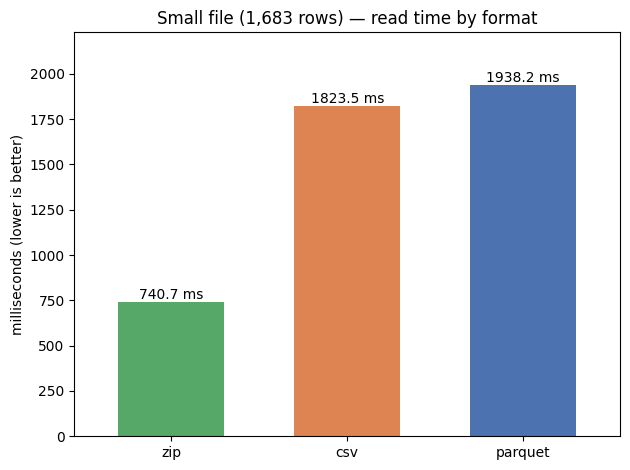

In [8]:
# bar chart
ms = pd.Series(small).sort_values() * 1000
ax = ms.plot(kind='bar', color=[colors[f] for f in ms.index], width=0.6)
ax.set_title('Small file (1,683 rows) — read time by format')
ax.set_ylabel('milliseconds (lower is better)')
ax.set_xlabel('')
plt.xticks(rotation=0)
for i, v in enumerate(ms):
    ax.text(i, v, f'{v:.1f} ms', ha='center', va='bottom')
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## Medium file — 1,000,000 rows

In [9]:
with Timer() as t_pd:
    df = pd.read_parquet(base + 'medium.parquet')
medium['parquet'] = t_pd.interval
print('parquet:', t_pd.interval, 'seconds')
df.head()

parquet: 3.074399099998118 seconds


,State,Year,Beer,Wine,Spirits
0,MO,2016,2.143,1.467,2.044
1,NE,1981,2.776,0.196,1.344
2,RI,2017,0.756,0.119,0.659
3,WI,2014,1.388,0.336,1.108
4,AK,2002,2.832,0.390,0.273


In [10]:
with Timer() as t_pd:
    df = pd.read_csv(base + 'medium.csv')
medium['csv'] = t_pd.interval
print('csv:', t_pd.interval, 'seconds')
df.head()

csv: 8.799386399998184 seconds


,State,Year,Beer,Wine,Spirits
0,MO,2016,2.143,1.467,2.044
1,NE,1981,2.776,0.196,1.344
2,RI,2017,0.756,0.119,0.659
3,WI,2014,1.388,0.336,1.108
4,AK,2002,2.832,0.390,0.273


In [11]:
with Timer() as t_pd:
    df = pd.read_csv(base + 'medium.zip', compression='zip')
medium['zip'] = t_pd.interval
print('zip:', t_pd.interval, 'seconds')
df.head()

zip: 4.2496938000003865 seconds


,State,Year,Beer,Wine,Spirits
0,MO,2016,2.143,1.467,2.044
1,NE,1981,2.776,0.196,1.344
2,RI,2017,0.756,0.119,0.659
3,WI,2014,1.388,0.336,1.108
4,AK,2002,2.832,0.390,0.273


In [12]:
medium_table = pd.Series(medium, name='seconds').sort_values().to_frame()
medium_table['x_vs_fastest'] = (medium_table['seconds'] / medium_table['seconds'].min()).round(2)
print('fastest:', medium_table.index[0])
medium_table

fastest: parquet


,seconds,x_vs_fastest
parquet,3.074399,1.00
zip,4.249694,1.38
csv,8.799386,2.86


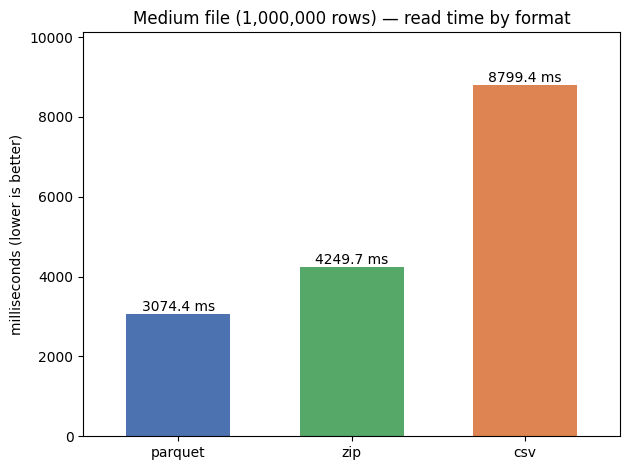

In [13]:
ms = pd.Series(medium).sort_values() * 1000
ax = ms.plot(kind='bar', color=[colors[f] for f in ms.index], width=0.6)
ax.set_title('Medium file (1,000,000 rows) — read time by format')
ax.set_ylabel('milliseconds (lower is better)')
ax.set_xlabel('')
plt.xticks(rotation=0)
for i, v in enumerate(ms):
    ax.text(i, v, f'{v:.1f} ms', ha='center', va='bottom')
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

At a million rows Parquet is clearly fastest

## Large file — 3,000,000 rows

In [14]:
with Timer() as t_pd:
    df = pd.read_parquet(base + 'large.parquet')
large['parquet'] = t_pd.interval
print('parquet:', t_pd.interval, 'seconds')
df.head()

parquet: 6.0719295000017155 seconds


,State,Year,Beer,Wine,Spirits
0,TX,1973,1.279,1.250,1.066
1,IN,1998,1.479,1.267,0.465
2,CO,1997,0.658,1.423,2.012
3,KS,1982,0.565,0.938,1.238
4,MI,1979,1.792,1.398,1.862


In [15]:
with Timer() as t_pd:
    df = pd.read_csv(base + 'large.csv')
large['csv'] = t_pd.interval
print('csv:', t_pd.interval, 'seconds')
df.head()

csv: 16.65005210000163 seconds


,State,Year,Beer,Wine,Spirits
0,TX,1973,1.279,1.250,1.066
1,IN,1998,1.479,1.267,0.465
2,CO,1997,0.658,1.423,2.012
3,KS,1982,0.565,0.938,1.238
4,MI,1979,1.792,1.398,1.862


In [16]:
with Timer() as t_pd:
    df = pd.read_csv(base + 'large.zip', compression='zip')
large['zip'] = t_pd.interval
print('zip:', t_pd.interval, 'seconds')
df.head()

zip: 8.023547699998744 seconds


,State,Year,Beer,Wine,Spirits
0,TX,1973,1.279,1.250,1.066
1,IN,1998,1.479,1.267,0.465
2,CO,1997,0.658,1.423,2.012
3,KS,1982,0.565,0.938,1.238
4,MI,1979,1.792,1.398,1.862


In [17]:
large_table = pd.Series(large, name='seconds').sort_values().to_frame()
large_table['x_vs_fastest'] = (large_table['seconds'] / large_table['seconds'].min()).round(2)
print('fastest:', large_table.index[0])
large_table

fastest: parquet


,seconds,x_vs_fastest
parquet,6.071930,1.00
zip,8.023548,1.32
csv,16.650052,2.74


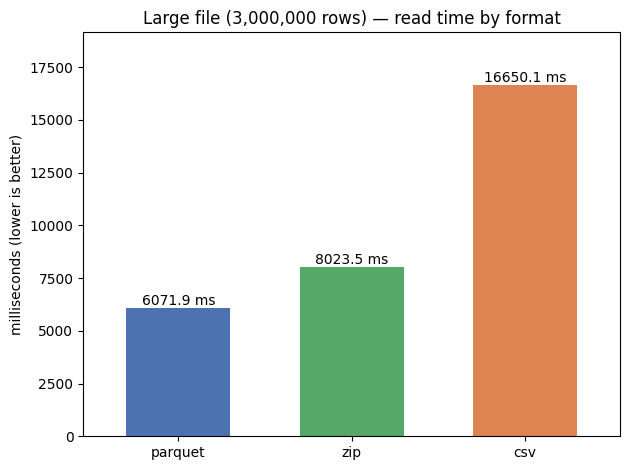

In [18]:
ms = pd.Series(large).sort_values() * 1000
ax = ms.plot(kind='bar', color=[colors[f] for f in ms.index], width=0.6)
ax.set_title('Large file (3,000,000 rows) — read time by format')
ax.set_ylabel('milliseconds (lower is better)')
ax.set_xlabel('')
plt.xticks(rotation=0)
for i, v in enumerate(ms):
    ax.text(i, v, f'{v:.1f} ms', ha='center', va='bottom')
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

Parquet stays well ahead while the CSV and zipped CSV climb

## All three sizes together

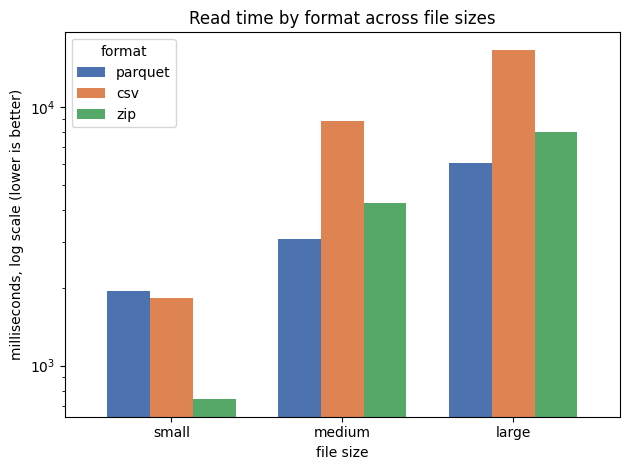

In [19]:
all_ms = (pd.DataFrame({'small': small, 'medium': medium, 'large': large}).T
          .loc[['small', 'medium', 'large'], ['parquet', 'csv', 'zip']] * 1000)

ax = all_ms.plot(kind='bar', color=[colors[f] for f in all_ms.columns], width=0.75)
ax.set_yscale('log')
ax.set_title('Read time by format across file sizes')
ax.set_ylabel('milliseconds, log scale (lower is better)')
ax.set_xlabel('file size')
plt.xticks(rotation=0)
ax.legend(title='format')
plt.tight_layout()
plt.show()

## Interactive view

A Seaborn chart, then a Bokeh chart. Each format keeps its colour: Parquet blue, CSV orange, zip green.

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

rows = {'small': 1683, 'medium': 1_000_000, 'large': 3_000_000}
palette = {'parquet': '#4C72B0', 'csv': '#DD8452', 'zip': '#55A868'}

# tidy long table: one row per (size, format); times are seconds, so x1000 for ms
tidy = pd.DataFrame([
    {'size': s, 'rows': rows[s], 'format': f, 'ms': d[f] * 1000}
    for s, d in [('small', small), ('medium', medium), ('large', large)]
    for f in ['parquet', 'csv', 'zip']
])
tidy

,size,rows,format,ms
0,small,1683,parquet,1938.2083
1,small,1683,csv,1823.5210
2,small,1683,zip,740.6739
3,medium,1000000,parquet,3074.3991
4,medium,1000000,csv,8799.3864
5,medium,1000000,zip,4249.6938
6,large,3000000,parquet,6071.9295
7,large,3000000,csv,16650.0521
8,large,3000000,zip,8023.5477


### Seaborn — how read time grows with rows

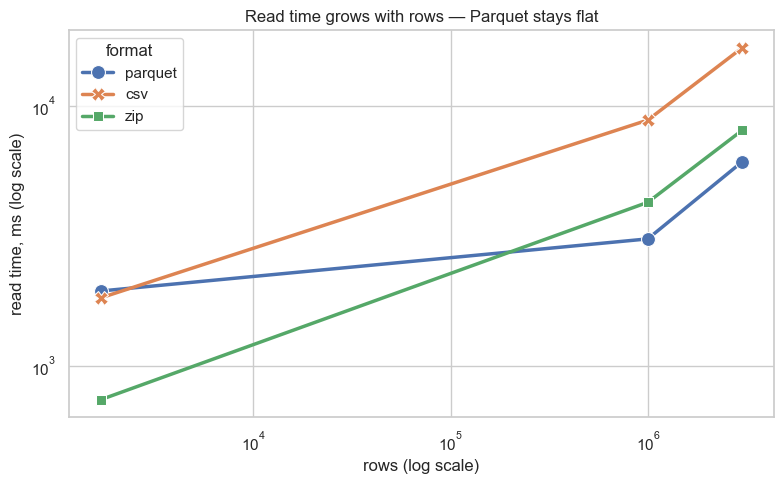

In [21]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 5))
ax = sns.lineplot(data=tidy, x='rows', y='ms', hue='format', style='format',
                  markers=True, dashes=False, markersize=10, linewidth=2.5, palette=palette)
ax.set(xscale='log', yscale='log',
       xlabel='rows (log scale)', ylabel='read time, ms (log scale)',
       title='Read time grows with rows — Parquet stays flat')
plt.tight_layout()
plt.show()

### Seaborn — formats grouped by file size

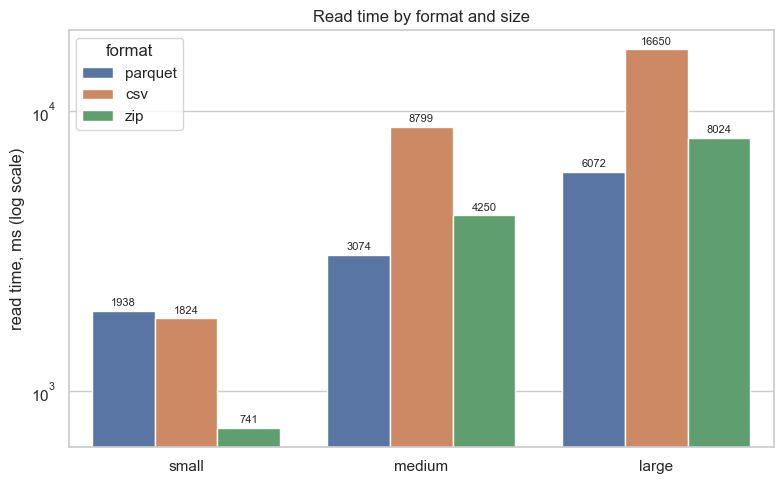

In [22]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=tidy, x='size', y='ms', hue='format', palette=palette,
                 order=['small', 'medium', 'large'])
ax.set_yscale('log')
ax.set(xlabel='', ylabel='read time, ms (log scale)', title='Read time by format and size')
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f', padding=2, fontsize=8)
plt.tight_layout()
plt.show()

### Bokeh — interactive

In [23]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import ColumnDataSource, HoverTool
output_notebook()

p = figure(height=420, width=760, x_axis_type='log', y_axis_type='log',
           title='Read time vs rows  (hover for the exact numbers)',
           x_axis_label='rows (log scale)', y_axis_label='read time, ms (log scale)',
           background_fill_color='#fafafa')

for f in ['parquet', 'csv', 'zip']:
    src = ColumnDataSource(dict(
        x=[rows[s] for s in ['small', 'medium', 'large']],
        y=[d[f] * 1000 for d in [small, medium, large]],
        fmt=[f] * 3, size=['small', 'medium', 'large']))
    p.line('x', 'y', source=src, color=palette[f], line_width=3, legend_label=f)
    pts = p.scatter('x', 'y', source=src, size=12, color=palette[f],
                    line_color='white', line_width=1.5)
    p.add_tools(HoverTool(renderers=[pts], tooltips=[
        ('format', '@fmt'), ('size', '@size'), ('rows', '@x{0,0}'), ('read time', '@y{0.0} ms')]))

p.legend.location = 'top_left'; p.legend.title = 'format'
show(p)

Loading BokehJS ...

**File Format Read Speed - Interactive.html**

In [27]:
from bokeh.plotting import figure, save
from bokeh.models import ColumnDataSource, HoverTool, FactorRange, Div
from bokeh.layouts import column
from bokeh.resources import INLINE
from bokeh.io import output_file

COL = {'parquet': '#4C72B0', 'csv': '#DD8452', 'zip': '#55A868'}
sizes, fmts = ['small', 'medium', 'large'], ['parquet', 'csv', 'zip']
rows = {'small': 1683, 'medium': 1_000_000, 'large': 3_000_000}
ms = {'small': {f: small[f]  * 1000 for f in fmts},
      'medium': {f: medium[f] * 1000 for f in fmts},
      'large': {f: large[f]  * 1000 for f in fmts}}
mb = {'small':  {'parquet': 0.0118, 'csv': 0.0511, 'zip': 0.0115},
      'medium': {'parquet': 5.94,   'csv': 25.67,  'zip': 9.20},
      'large':  {'parquet': 17.80,  'csv': 61.93,  'zip': 21.01}}

output_file("Notebook2.5.html", title="File formats: speed & size")

title = Div(text="""<div style="font-family:Segoe UI,Arial,sans-serif;max-width:880px">
<h1 style="margin:0 0 4px 0;color:#2a2a2a">Parquet vs CSV vs Zipped CSV</h1>
<p style="margin:0;color:#666;font-size:15px">Reading the same table at three sizes. </p></div>""")

p1 = figure(height=380, width=860, x_axis_type='log', y_axis_type='log',
            title="How read time grows with the number of rows",
            x_axis_label='rows (log scale)', y_axis_label='read time, ms (log scale)',
            tools="pan,wheel_zoom,box_zoom,reset,save", background_fill_color="#fafafa")
for f in fmts:
    src = ColumnDataSource(dict(x=[rows[s] for s in sizes], y=[ms[s][f] for s in sizes],
                                fmt=[f] * 3, size=sizes))
    p1.line('x', 'y', source=src, line_width=3, color=COL[f], legend_label=f)
    r = p1.scatter('x', 'y', source=src, size=11, color=COL[f], line_color='white', line_width=1.5)
    p1.add_tools(HoverTool(renderers=[r], tooltips=[('format', '@fmt'), ('size', '@size'),
                 ('rows', '@x{0,0}'), ('read time', '@y{0.0} ms')]))
p1.legend.location = 'top_left'; p1.legend.title = 'format'

def grouped(metric, ylabel, title_txt, unit, bottom):
    factors = [(s, f) for s in sizes for f in fmts]
    vals = [metric[s][f] for s in sizes for f in fmts]
    src = ColumnDataSource(dict(x=factors, top=vals,
        color=[COL[f] for s in sizes for f in fmts],
        fmt=[f for s in sizes for f in fmts],
        size=[s for s in sizes for f in fmts], val=vals))
    p = figure(height=360, width=860, x_range=FactorRange(*factors), y_axis_type='log',
               title=title_txt, y_axis_label=ylabel, tools="save,reset", background_fill_color="#fafafa")
    p.vbar(x='x', top='top', bottom=bottom, width=0.85, source=src, fill_color='color', line_color='white')
    p.add_tools(HoverTool(tooltips=[('size', '@size'), ('format', '@fmt'), (ylabel, '@val{0.000} ' + unit)]))
    p.y_range.start = bottom; p.xaxis.major_label_orientation = 0.8; p.xgrid.grid_line_color = None
    return p

p2 = grouped(ms, 'milliseconds', 'Read time by format and size (log scale)', 'ms', 0.1)
p3 = grouped(mb, 'megabytes', 'File size on disk by format and size (log scale)', 'MB', 0.001)

save(column(title, p1, p2, p3), resources=INLINE)
print("Interactive.html")

Interactive.html


## In short

Checked one size at a time, the story is consistent: on the small file the format hardly matters, but as the file grows Parquet wins by a wider margin on read time.